### Load df_artists_final

In [1]:
# Load df_artists_final from CSV
import pandas as pd

df_artists_final = pd.read_csv(
    '/Users/jamesemcnally/Documents/GitHub/spring-2026-hitmakers/df_artists_final.csv',
    index_col=0
)

print(df_artists_final.shape)
print(df_artists_final.columns.tolist())


(759, 26)
['#_of_charting_songs_through_first_top_20_hit', 'top_20_hit_song_#_wks_on_chart_any_position', 'artist_genre_Blues', 'artist_genre_Classical', 'artist_genre_Country/Americana', 'artist_genre_Easy Listening/Vocal', 'artist_genre_Electronic/Dance', 'artist_genre_Experimental/Avant-Garde', 'artist_genre_Folk', 'artist_genre_Gospel/Christian/Religious', 'artist_genre_Hip Hop/Rap', 'artist_genre_Jazz', 'artist_genre_Latin', 'artist_genre_Metal', 'artist_genre_Pop', 'artist_genre_Punk/Hardcore', 'artist_genre_R&B/Soul/Funk', 'artist_genre_Reggae/Caribbean', 'artist_genre_Rock', 'artist_genre_World Music', 'artist_genre_unknown', '#_of_genres_artist', 'harmonic_closeness_centrality_top20_rolling5', 'betweenness_centrality_top20_rolling5', 'eigenvector_centrality_top20_rolling5', 'top_20_hitmaker']


## Model

In [2]:
# Separate features and target
X = df_artists_final.drop(columns=['top_20_hitmaker'])
y = df_artists_final['top_20_hitmaker']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\ny value counts:\n{y.value_counts()}")
print(f"\ny class balance:\n{y.value_counts(normalize=True).round(3)}")


X shape: (759, 25)
y shape: (759,)

y value counts:
top_20_hitmaker
0.0    431
1.0    328
Name: count, dtype: int64

y class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64


In [3]:
# Split into train and test sets, stratified to preserve class balance
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (607, 25), Test: (152, 25)

Train class balance:
top_20_hitmaker
0.0    0.568
1.0    0.432
Name: proportion, dtype: float64

Test class balance:
top_20_hitmaker
0.0    0.566
1.0    0.434
Name: proportion, dtype: float64


In [4]:
# Scale features for models sensitive to feature magnitude (Logistic Regression, SVM)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")


Scaling complete.
X_train_scaled shape: (607, 25)


In [8]:
# Evaluate Dummy, Logistic Regression, SVM, Random Forest, and XGBoost
# using 5-fold cross-validation on training set only.
# sklearn models are wrapped in a Pipeline with median imputation to handle NaNs in X_train.
# Logistic Regression also includes StandardScaler to aid convergence.

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import numpy as np

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss']

imputer = SimpleImputer(strategy='median')

models = {
    'Dummy':               DummyClassifier(strategy='stratified', random_state=42),
    'Logistic Regression': make_pipeline(imputer, StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'SVM':                 make_pipeline(imputer, SVC(probability=True, random_state=42)),
    'Random Forest':       make_pipeline(imputer, RandomForestClassifier(n_estimators=100, random_state=42)),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
}

results = []
for name, model in models.items():
    cv = cross_validate(model, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)
    results.append({
        'Model':           name,
        'Accuracy':        cv['test_accuracy'].mean(),
        'Precision':       cv['test_precision'].mean(),
        'Recall':          cv['test_recall'].mean(),
        'F1':              cv['test_f1'].mean(),
        'ROC-AUC (CV)':    cv['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv['train_roc_auc'].mean(),
        'Overfit Gap':     cv['train_roc_auc'].mean() - cv['test_roc_auc'].mean(),
        'Log Loss':        -cv['test_neg_log_loss'].mean(),
    })

df_results = pd.DataFrame(results).set_index('Model').round(3)
print(df_results)


                     Accuracy  Precision  Recall     F1  ROC-AUC (CV)  \
Model                                                                   
Dummy                   0.503      0.421   0.405  0.413         0.491   
Logistic Regression     0.676      0.654   0.531  0.579         0.716   
SVM                     0.634      0.751   0.240  0.363         0.612   
Random Forest           0.656      0.611   0.569  0.589         0.722   
XGBoost                 0.633      0.580   0.542  0.559         0.693   

                     ROC-AUC (Train)  Overfit Gap  Log Loss  
Model                                                        
Dummy                          0.490       -0.001    17.931  
Logistic Regression            0.767        0.051     0.639  
SVM                            0.634        0.021     0.662  
Random Forest                  0.990        0.268     0.619  
XGBoost                        0.996        0.304     0.873  


In [9]:
# Lightweight regularization pass for XGBoost and Random Forest.
# Goal: close overfit gap before committing to full hyperparameter search.
# 20 iterations each, focused on depth and leaf/child weight controls.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

imputer = SimpleImputer(strategy='median')

# --- XGBoost ---
xgb_reg_grid = {
    'max_depth':        randint(2, 5),
    'min_child_weight': randint(10, 30),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
}

xgb_reg_search = RandomizedSearchCV(
    XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    xgb_reg_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_reg_search.fit(X_train, y_train)

cv = cross_validate(xgb_reg_search.best_estimator_, X_train, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
print("XGBoost")
print(f"  Best params:     {xgb_reg_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")

# --- Random Forest ---
rf_reg_grid = {
    'randomforestclassifier__n_estimators':  randint(100, 500),
    'randomforestclassifier__max_depth':     randint(2, 8),
    'randomforestclassifier__min_samples_leaf': randint(5, 30),
    'randomforestclassifier__max_features':  uniform(0.3, 0.5),
}

rf_reg_search = RandomizedSearchCV(
    make_pipeline(imputer, RandomForestClassifier(random_state=42)),
    rf_reg_grid,
    n_iter=20, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
rf_reg_search.fit(X_train, y_train)

cv = cross_validate(rf_reg_search.best_estimator_, X_train, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
print("\nRandom Forest")
print(f"  Best params:     {rf_reg_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBoost
  Best params:     {'colsample_bytree': np.float64(0.6872700594236812), 'max_depth': 2, 'min_child_weight': 24, 'reg_alpha': np.float64(4.659969709057025), 'reg_lambda': np.float64(8.986584841970366), 'subsample': np.float64(0.6624074561769746)}
  ROC-AUC (CV):    0.751 ± 0.038
  ROC-AUC (Train): 0.779
  Overfit Gap:     0.028
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest
  Best params:     {'randomforestclassifier__max_depth': 4, 'randomforestclassifier__max_features': np.float64(0.3102922471479012), 'randomforestclassifier__min_samples_leaf': 6, 'randomforestclassifier__n_estimators': 443}
  ROC-AUC (CV):    0.751 ± 0.039
  ROC-AUC (Train): 0.842
  Overfit Gap:     0.091


In [10]:
# Full hyperparameter search for XGBoost, Random Forest, Logistic Regression, and SVM.
# Iterations tuned per model to keep total runtime under ~5 minutes.
# All sklearn models use median imputation; LR and SVM also use StandardScaler.
# Prints per-model ROC-AUC summary and a final comparison table across all metrics.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from scipy.stats import randint, uniform, loguniform
import numpy as np
import pandas as pd

imputer = SimpleImputer(strategy='median')

full_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss']
all_results = []

def eval_search(name, search, X, y):
    search.fit(X, y)
    # Quick ROC-AUC summary
    cv_roc = cross_validate(search.best_estimator_, X, y, cv=5,
                            scoring='roc_auc', return_train_score=True)
    print(f"\n{name}")
    print(f"  Best params:     {search.best_params_}")
    print(f"  ROC-AUC (CV):    {cv_roc['test_score'].mean():.3f} ± {cv_roc['test_score'].std():.3f}")
    print(f"  ROC-AUC (Train): {cv_roc['train_score'].mean():.3f}")
    print(f"  Overfit Gap:     {cv_roc['train_score'].mean() - cv_roc['test_score'].mean():.3f}")
    # Full metrics for comparison table
    cv_full = cross_validate(search.best_estimator_, X, y, cv=5,
                             scoring=full_scoring, return_train_score=True)
    all_results.append({
        'Model':           name,
        'Accuracy':        cv_full['test_accuracy'].mean(),
        'Precision':       cv_full['test_precision'].mean(),
        'Recall':          cv_full['test_recall'].mean(),
        'F1':              cv_full['test_f1'].mean(),
        'ROC-AUC (CV)':    cv_full['test_roc_auc'].mean(),
        'ROC-AUC (Train)': cv_full['train_roc_auc'].mean(),
        'Overfit Gap':     cv_full['train_roc_auc'].mean() - cv_full['test_roc_auc'].mean(),
        'Log Loss':        -cv_full['test_neg_log_loss'].mean(),
    })
    return search

# --- XGBoost (100 iter) ---
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    {
        'n_estimators':     randint(100, 400),
        'max_depth':        randint(2, 5),
        'learning_rate':    uniform(0.01, 0.1),
        'min_child_weight': randint(10, 30),
        'subsample':        uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.5, 0.5),
        'reg_alpha':        uniform(1, 5),
        'reg_lambda':       uniform(3, 10),
    },
    n_iter=100, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)
xgb_search = eval_search("XGBoost", xgb_search, X_train, y_train)

# --- Random Forest (30 iter) ---
rf_search = RandomizedSearchCV(
    make_pipeline(imputer, RandomForestClassifier(random_state=42)),
    {
        'randomforestclassifier__n_estimators':     randint(100, 400),
        'randomforestclassifier__max_depth':        randint(2, 8),
        'randomforestclassifier__min_samples_leaf': randint(5, 30),
        'randomforestclassifier__max_features':     uniform(0.3, 0.5),
    },
    n_iter=30, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)
rf_search = eval_search("Random Forest", rf_search, X_train, y_train)

# --- Logistic Regression (30 iter) ---
lr_search = RandomizedSearchCV(
    make_pipeline(imputer, StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    {
        'logisticregression__C':       loguniform(1e-3, 1e2),
        'logisticregression__penalty': ['l2'],
    },
    n_iter=30, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)
lr_search = eval_search("Logistic Regression", lr_search, X_train, y_train)

# --- SVM (10 iter — slowest model) ---
svm_search = RandomizedSearchCV(
    make_pipeline(imputer, StandardScaler(), SVC(probability=True, random_state=42)),
    {
        'svc__C':      loguniform(1e-2, 1e2),
        'svc__gamma':  ['scale', 'auto'],
        'svc__kernel': ['rbf', 'linear'],
    },
    n_iter=10, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1
)
svm_search = eval_search("SVM", svm_search, X_train, y_train)

# --- Final comparison table ---
print("\n\n=== Tuned Model Comparison ===")
df_tuned = pd.DataFrame(all_results).set_index('Model').round(3)
print(df_tuned)


Fitting 5 folds for each of 100 candidates, totalling 500 fits

XGBoost
  Best params:     {'colsample_bytree': np.float64(0.6033421799383727), 'learning_rate': np.float64(0.03739611273211338), 'max_depth': 4, 'min_child_weight': 23, 'n_estimators': 352, 'reg_alpha': np.float64(1.472214803779642), 'reg_lambda': np.float64(9.830067734163569), 'subsample': np.float64(0.6284754593840916)}
  ROC-AUC (CV):    0.751 ± 0.037
  ROC-AUC (Train): 0.784
  Overfit Gap:     0.033
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Forest
  Best params:     {'randomforestclassifier__max_depth': 4, 'randomforestclassifier__max_features': np.float64(0.3102922471479012), 'randomforestclassifier__min_samples_leaf': 6, 'randomforestclassifier__n_estimators': 393}
  ROC-AUC (CV):    0.751 ± 0.040
  ROC-AUC (Train): 0.842
  Overfit Gap:     0.091
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Logistic Regression
  Best params:     {'logisticregression__C': np.float64(0.001

## Final model evaluation

##### XGBoost is the strongest model. Now examining it in detail.

In [12]:
# Final evaluation of tuned XGBoost on the held-out test set.
# Reports ROC-AUC, log loss, accuracy, precision, recall, F1, and overfit gap.

from sklearn.metrics import (roc_auc_score, log_loss, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
from sklearn.model_selection import cross_validate

model = xgb_search.best_estimator_
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
cv = cross_validate(model, X_train, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)

print("=" * 52)
print("XGBoost — Final Evaluation")
print("=" * 52)
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
print(f"  Log Loss (Test): {log_loss(y_test, y_proba):.3f}")
print(f"  Accuracy (Test): {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision (Test):{precision_score(y_test, y_pred):.3f}")
print(f"  Recall (Test):   {recall_score(y_test, y_pred):.3f}")
print(f"  F1 (Test):       {f1_score(y_test, y_pred):.3f}")
print(f"\n{classification_report(y_test, y_pred)}")


XGBoost — Final Evaluation
  ROC-AUC (CV):    0.751 ± 0.037
  ROC-AUC (Train): 0.784
  ROC-AUC (Test):  0.763
  Overfit Gap:     0.033
  Log Loss (Test): 0.567
  Accuracy (Test): 0.697
  Precision (Test):0.661
  Recall (Test):   0.621
  F1 (Test):       0.641

              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74        86
         1.0       0.66      0.62      0.64        66

    accuracy                           0.70       152
   macro avg       0.69      0.69      0.69       152
weighted avg       0.70      0.70      0.70       152



XGBoost — Final Model Evaluation
  ROC-AUC (Test):   0.763
  Log Loss (Test):  0.567
  Brier Score:      0.193
  Accuracy:         0.697
  Precision:        0.661
  Recall:           0.621
  F1:               0.641

              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74        86
         1.0       0.66      0.62      0.64        66

    accuracy                           0.70       152
   macro avg       0.69      0.69      0.69       152
weighted avg       0.70      0.70      0.70       152



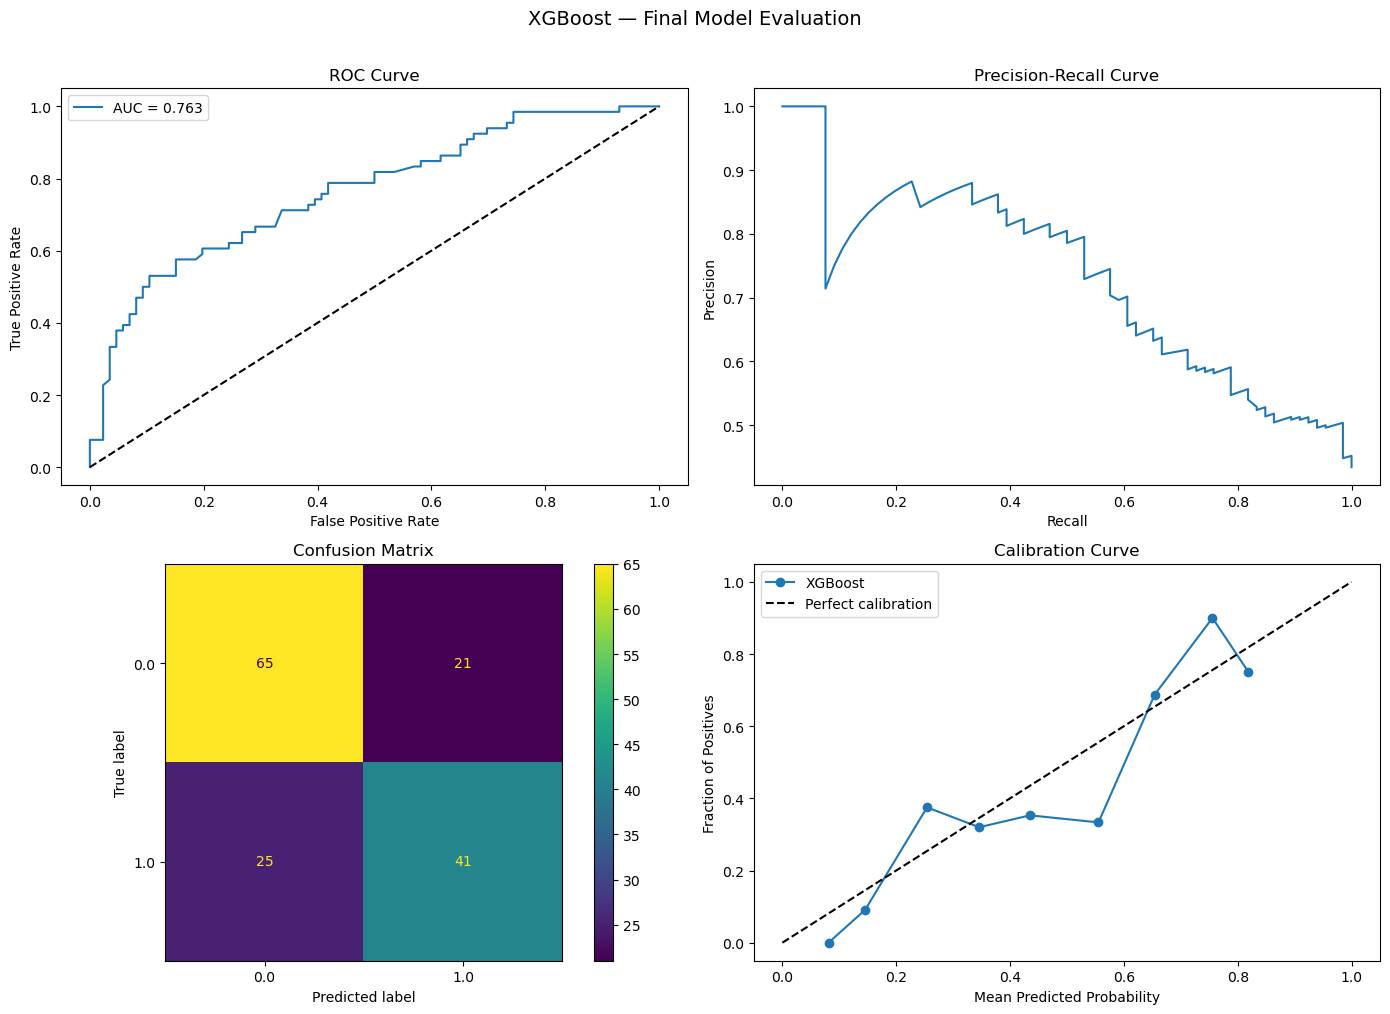


Feature Importance (mean absolute SHAP):
                                     feature  mean_abs_shap
#_of_charting_songs_through_first_top_20_hit       0.602988
       betweenness_centrality_top20_rolling5       0.258665
       eigenvector_centrality_top20_rolling5       0.230185
                            artist_genre_Pop       0.203804
                    artist_genre_Hip Hop/Rap       0.192612
 top_20_hit_song_#_wks_on_chart_any_position       0.185758
                          #_of_genres_artist       0.179611
harmonic_closeness_centrality_top20_rolling5       0.161514
                           artist_genre_Rock       0.002784
                  artist_genre_Punk/Hardcore       0.000000
                          artist_genre_Blues       0.000000
                        artist_genre_unknown       0.000000
                    artist_genre_World Music       0.000000
               artist_genre_Reggae/Caribbean       0.000000
                  artist_genre_R&B/Soul/Funk       0.00000

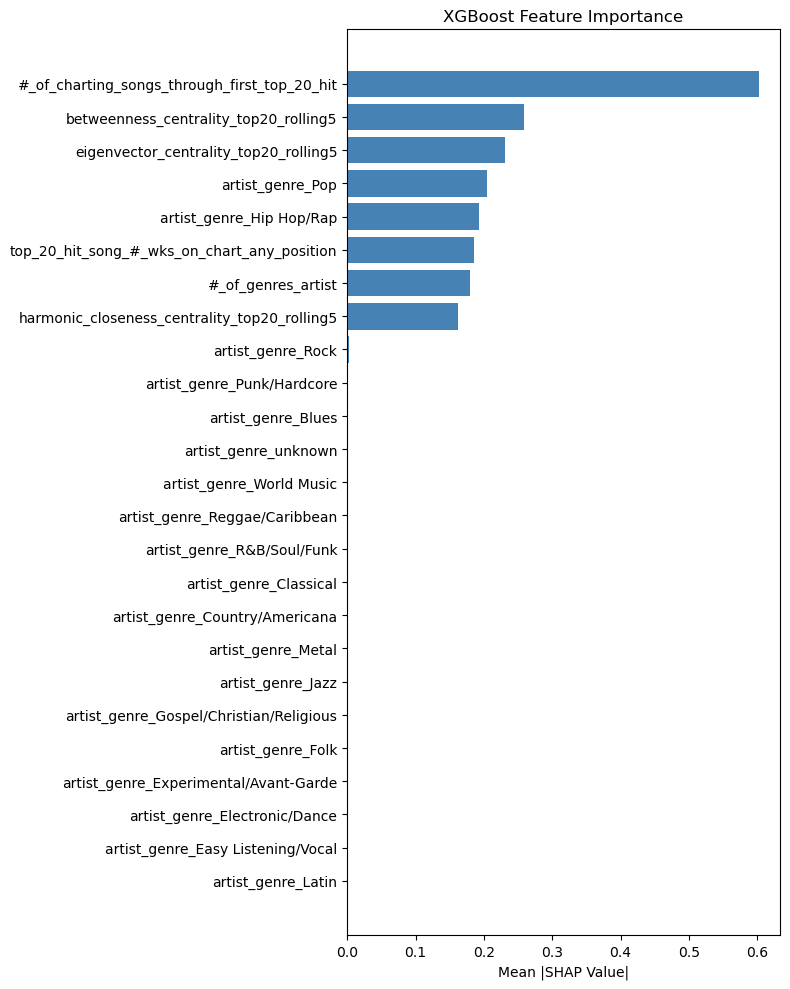

In [13]:
# Deep evaluation of tuned XGBoost as final model.
# Includes ROC curve, confusion matrix, precision-recall curve,
# SHAP feature importance, and calibration curve.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve

best_xgb = xgb_search.best_estimator_
y_pred  = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# --- Summary stats ---
print("=" * 52)
print("XGBoost — Final Model Evaluation")
print("=" * 52)
print(f"  ROC-AUC (Test):   {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Log Loss (Test):  {log_loss(y_test, y_proba):.3f}")
print(f"  Brier Score:      {brier_score_loss(y_test, y_proba):.3f}")
print(f"  Accuracy:         {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision:        {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:           {recall_score(y_test, y_pred):.3f}")
print(f"  F1:               {f1_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred))

# --- Plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[0, 1].plot(rec, prec)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix')

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker='o', label='XGBoost')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1, 1].set_xlabel('Mean Predicted Probability')
axes[1, 1].set_ylabel('Fraction of Positives')
axes[1, 1].set_title('Calibration Curve')
axes[1, 1].legend()

plt.suptitle('XGBoost — Final Model Evaluation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- SHAP feature importance ---
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap_importance = (
    pd.DataFrame({
        'feature': X_test.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print("\nFeature Importance (mean absolute SHAP):")
print(shap_importance.to_string(index=False))

plt.figure(figsize=(8, 10))
plt.barh(shap_importance['feature'][::-1], shap_importance['mean_abs_shap'][::-1], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


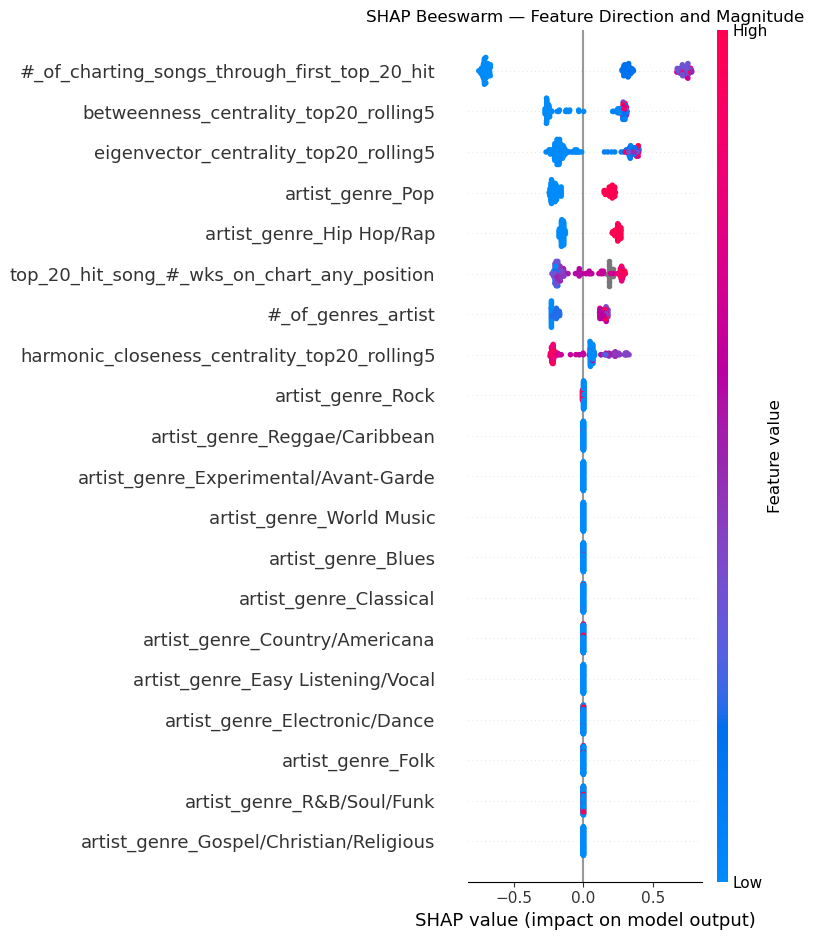

In [14]:
# SHAP beeswarm plot showing both magnitude and direction of feature contributions.
# Red = high feature value, Blue = low feature value.
# X-axis position shows whether the feature pushes toward hitmaker (positive) or one-hit wonder (negative).

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Feature Direction and Magnitude')
plt.tight_layout()
plt.show()


## Feature contribution analysis

##### Can we pare down features to further tune our model?

##### First, ablation analysis

In [15]:
# Ablation analysis for tuned XGBoost — drops each feature one at a time and compares CV AUC.
# Positive delta = dropping the feature HELPS. Negative = it HURTS.

from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

baseline_cv = cross_validate(xgb_search.best_estimator_, X_train, y_train, cv=5,
                             scoring='roc_auc', return_train_score=False)
baseline_auc = baseline_cv['test_score'].mean()
baseline_test = roc_auc_score(y_test, xgb_search.best_estimator_.predict_proba(X_test)[:, 1])

results_ablation = []
for col in X_train.columns:
    X_tr = X_train.drop(columns=[col])
    X_te = X_test.drop(columns=[col])

    model = XGBClassifier(random_state=42, eval_metric='logloss',
                          **xgb_search.best_params_)
    cv = cross_validate(model, X_tr, y_train, cv=5,
                        scoring='roc_auc', return_train_score=False)
    model.fit(X_tr, y_train)
    test_auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])

    results_ablation.append({
        'feature':          col,
        'CV AUC (drop)':    cv['test_score'].mean(),
        'Test AUC (drop)':  test_auc,
        'CV AUC delta':     cv['test_score'].mean() - baseline_auc,
        'Test AUC delta':   test_auc - baseline_test,
    })

df_ablation = (
    pd.DataFrame(results_ablation)
    .sort_values('CV AUC delta', ascending=False)
    .reset_index(drop=True)
)

print(f"Baseline CV AUC:   {baseline_auc:.3f}")
print(f"Baseline Test AUC: {baseline_test:.3f}")
print()
print("Positive delta = dropping the feature HELPS. Negative = it HURTS.")
print(df_ablation.to_string(index=False))


Baseline CV AUC:   0.751
Baseline Test AUC: 0.763

Positive delta = dropping the feature HELPS. Negative = it HURTS.
                                     feature  CV AUC (drop)  Test AUC (drop)  CV AUC delta  Test AUC delta
 top_20_hit_song_#_wks_on_chart_any_position       0.754345         0.757664      0.003122       -0.005726
                          artist_genre_Blues       0.751542         0.766913      0.000320        0.003524
                      artist_genre_Classical       0.751542         0.766913      0.000320        0.003524
              artist_genre_Country/Americana       0.751542         0.766913      0.000320        0.003524
           artist_genre_Easy Listening/Vocal       0.751542         0.766913      0.000320        0.003524
               artist_genre_Electronic/Dance       0.751542         0.766913      0.000320        0.003524
       artist_genre_Experimental/Avant-Garde       0.751542         0.766913      0.000320        0.003524
                           

In [17]:
# Compare full model vs. model with eigenvector_centrality and weeks on chart dropped.
# Uses same best params from tuning.
# Full model stats are hardcoded from final evaluation cell above.

# Weeks on chart showed near-zero contribution in ablation (CV delta +0.000), 
# and eigenvector centrality improved test AUC when dropped (+0.008), 
# suggesting both features add complexity without contributing reliable signal.

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss, brier_score_loss, roc_auc_score)

cols_to_drop = [
    'eigenvector_centrality_top20_rolling5',
    'top_20_hit_song_#_wks_on_chart_any_position',
]

X_train_trim = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_test_trim  = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])

model_trim = XGBClassifier(random_state=42, eval_metric='logloss',
                           **xgb_search.best_params_)
cv_trim = cross_validate(model_trim, X_train_trim, y_train, cv=5,
                         scoring='roc_auc', return_train_score=True)
model_trim.fit(X_train_trim, y_train)
y_proba_trim = model_trim.predict_proba(X_test_trim)[:, 1]
y_pred_trim  = model_trim.predict(X_test_trim)

print("=" * 52)
print("Full model (hardcoded from final evaluation):")
print(f"  ROC-AUC (CV):    0.751 ± 0.037")
print(f"  ROC-AUC (Train): 0.784")
print(f"  ROC-AUC (Test):  0.763")
print(f"  Overfit Gap:     0.033")
print(f"  Log Loss:        0.567")
print(f"  Brier Score:     0.193")
print(f"  Accuracy:        0.697")
print(f"  Precision:       0.661")
print(f"  Recall:          0.621")
print(f"  F1:              0.641")

print("\nWithout eigenvector_centrality + weeks on chart:")
print(f"  ROC-AUC (CV):    {cv_trim['test_score'].mean():.3f} ± {cv_trim['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv_trim['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_trim):.3f}")
print(f"  Overfit Gap:     {cv_trim['train_score'].mean() - cv_trim['test_score'].mean():.3f}")
print(f"  Log Loss:        {log_loss(y_test, y_proba_trim):.3f}")
print(f"  Brier Score:     {brier_score_loss(y_test, y_proba_trim):.3f}")
print(f"  Accuracy:        {accuracy_score(y_test, y_pred_trim):.3f}")
print(f"  Precision:       {precision_score(y_test, y_pred_trim):.3f}")
print(f"  Recall:          {recall_score(y_test, y_pred_trim):.3f}")
print(f"  F1:              {f1_score(y_test, y_pred_trim):.3f}")


Full model (hardcoded from final evaluation):
  ROC-AUC (CV):    0.751 ± 0.037
  ROC-AUC (Train): 0.784
  ROC-AUC (Test):  0.763
  Overfit Gap:     0.033
  Log Loss:        0.567
  Brier Score:     0.193
  Accuracy:        0.697
  Precision:       0.661
  Recall:          0.621
  F1:              0.641

Without eigenvector_centrality + weeks on chart:
  ROC-AUC (CV):    0.753 ± 0.039
  ROC-AUC (Train): 0.774
  ROC-AUC (Test):  0.770
  Overfit Gap:     0.021
  Log Loss:        0.566
  Brier Score:     0.193
  Accuracy:        0.704
  Precision:       0.667
  Recall:          0.636
  F1:              0.651


In [20]:
# Compare trimmed model vs. trimmed model with genre consolidation.
# Consolidates low-signal genres + artist_genre_unknown into artist_genre_other.
# Keeps Hip Hop/Rap, Pop, Rock, R&B/Soul/Funk separate.
# Trimmed model stats are hardcoded from previous cell.

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss, brier_score_loss, roc_auc_score)

genres_to_consolidate = [
    'artist_genre_Punk/Hardcore', 'artist_genre_World Music',
    'artist_genre_Reggae/Caribbean', 'artist_genre_Metal',
    'artist_genre_Latin', 'artist_genre_Jazz', 'artist_genre_Classical',
    'artist_genre_Gospel/Christian/Religious', 'artist_genre_Folk',
    'artist_genre_Experimental/Avant-Garde', 'artist_genre_Electronic/Dance',
    'artist_genre_Easy Listening/Vocal', 'artist_genre_Country/Americana',
    'artist_genre_Blues', 'artist_genre_unknown',
]

X_train_consolidated = X_train_trim.copy()
X_test_consolidated  = X_test_trim.copy()

present_train = [c for c in genres_to_consolidate if c in X_train_consolidated.columns]
present_test  = [c for c in genres_to_consolidate if c in X_test_consolidated.columns]

X_train_consolidated['artist_genre_other'] = X_train_consolidated[present_train].max(axis=1).astype(int)
X_test_consolidated['artist_genre_other']  = X_test_consolidated[present_test].max(axis=1).astype(int)

X_train_consolidated = X_train_consolidated.drop(columns=present_train)
X_test_consolidated  = X_test_consolidated.drop(columns=present_test)

model_consolidated = XGBClassifier(random_state=42, eval_metric='logloss',
                                   **xgb_search.best_params_)
cv_consolidated = cross_validate(model_consolidated, X_train_consolidated, y_train, cv=5,
                                 scoring='roc_auc', return_train_score=True)
model_consolidated.fit(X_train_consolidated, y_train)
y_proba_consolidated = model_consolidated.predict_proba(X_test_consolidated)[:, 1]
y_pred_consolidated  = model_consolidated.predict(X_test_consolidated)

print("=" * 52)
print("Trimmed model (no eigenvector, no weeks on chart):")
print(f"  ROC-AUC (CV):    0.753 ± 0.039")
print(f"  ROC-AUC (Train): 0.774")
print(f"  ROC-AUC (Test):  0.770")
print(f"  Overfit Gap:     0.021")
print(f"  Log Loss:        0.566")
print(f"  Brier Score:     0.193")
print(f"  Accuracy:        0.704")
print(f"  Precision:       0.667")
print(f"  Recall:          0.636")
print(f"  F1:              0.651")

print("\nTrimmed + genre consolidation:")
print(f"  ROC-AUC (CV):    {cv_consolidated['test_score'].mean():.3f} ± {cv_consolidated['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv_consolidated['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_consolidated):.3f}")
print(f"  Overfit Gap:     {cv_consolidated['train_score'].mean() - cv_consolidated['test_score'].mean():.3f}")
print(f"  Log Loss:        {log_loss(y_test, y_proba_consolidated):.3f}")
print(f"  Brier Score:     {brier_score_loss(y_test, y_proba_consolidated):.3f}")
print(f"  Accuracy:        {accuracy_score(y_test, y_pred_consolidated):.3f}")
print(f"  Precision:       {precision_score(y_test, y_pred_consolidated):.3f}")
print(f"  Recall:          {recall_score(y_test, y_pred_consolidated):.3f}")
print(f"  F1:              {f1_score(y_test, y_pred_consolidated):.3f}")


Trimmed model (no eigenvector, no weeks on chart):
  ROC-AUC (CV):    0.753 ± 0.039
  ROC-AUC (Train): 0.774
  ROC-AUC (Test):  0.770
  Overfit Gap:     0.021
  Log Loss:        0.566
  Brier Score:     0.193
  Accuracy:        0.704
  Precision:       0.667
  Recall:          0.636
  F1:              0.651

Trimmed + genre consolidation:
  ROC-AUC (CV):    0.752 ± 0.036
  ROC-AUC (Train): 0.777
  ROC-AUC (Test):  0.774
  Overfit Gap:     0.025
  Log Loss:        0.565
  Brier Score:     0.193
  Accuracy:        0.704
  Precision:       0.672
  Recall:          0.621
  F1:              0.646


## Re-tune XGBoost with streamlined features

##### Previous analysis showed that genre consolidation was a wash in terms of model performance. Because genre consolidation (all but high importance genre features are converted to artist_genre_other) reduces complexity, we go with the more streamlined model: no eigenvector centrality, no weeks on chart, and all low importance genre features condensed to artist_genre_other.

In [21]:
# Re-tune XGBoost on trimmed + genre-consolidated feature set.
# Replaces X_train_trim/X_test_trim with X_train_consolidated/X_test_consolidated.

from sklearn.model_selection import RandomizedSearchCV, cross_validate
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
from sklearn.metrics import roc_auc_score

xgb_grid_consolidated = {
    'n_estimators':     randint(100, 400),
    'max_depth':        randint(2, 5),
    'learning_rate':    uniform(0.01, 0.1),
    'min_child_weight': randint(10, 30),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha':        uniform(1, 5),
    'reg_lambda':       uniform(3, 10),
}

xgb_consolidated_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_grid_consolidated,
    n_iter=100, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_consolidated_search.fit(X_train_consolidated, y_train)

cv = cross_validate(xgb_consolidated_search.best_estimator_, X_train_consolidated, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)
y_proba_consolidated_retuned = xgb_consolidated_search.best_estimator_.predict_proba(X_test_consolidated)[:, 1]

print("Re-tuned trimmed + genre-consolidated model:")
print(f"  Best params:     {xgb_consolidated_search.best_params_}")
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba_consolidated_retuned):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Re-tuned trimmed + genre-consolidated model:
  Best params:     {'colsample_bytree': np.float64(0.7560465291496405), 'learning_rate': np.float64(0.0326495775197938), 'max_depth': 4, 'min_child_weight': 29, 'n_estimators': 227, 'reg_alpha': np.float64(3.5887567526374005), 'reg_lambda': np.float64(11.37710105907328), 'subsample': np.float64(0.8702760468157122)}
  ROC-AUC (CV):    0.757 ± 0.037
  ROC-AUC (Train): 0.776
  ROC-AUC (Test):  0.763
  Overfit Gap:     0.018


##### Evaluating newly tuned XGBoost model with streamlined features

FINAL MODEL — XGBoost (re-tuned, trimmed + consolidated)
  ROC-AUC (CV):    0.757 ± 0.037
  ROC-AUC (Train): 0.776
  ROC-AUC (Test):  0.763
  Overfit Gap:     0.018
  Log Loss:        0.572
  Brier Score:     0.195
  Accuracy:        0.711
  Precision:       0.683
  Recall:          0.621
  F1:              0.651

              precision    recall  f1-score   support

         0.0       0.73      0.78      0.75        86
         1.0       0.68      0.62      0.65        66

    accuracy                           0.71       152
   macro avg       0.71      0.70      0.70       152
weighted avg       0.71      0.71      0.71       152



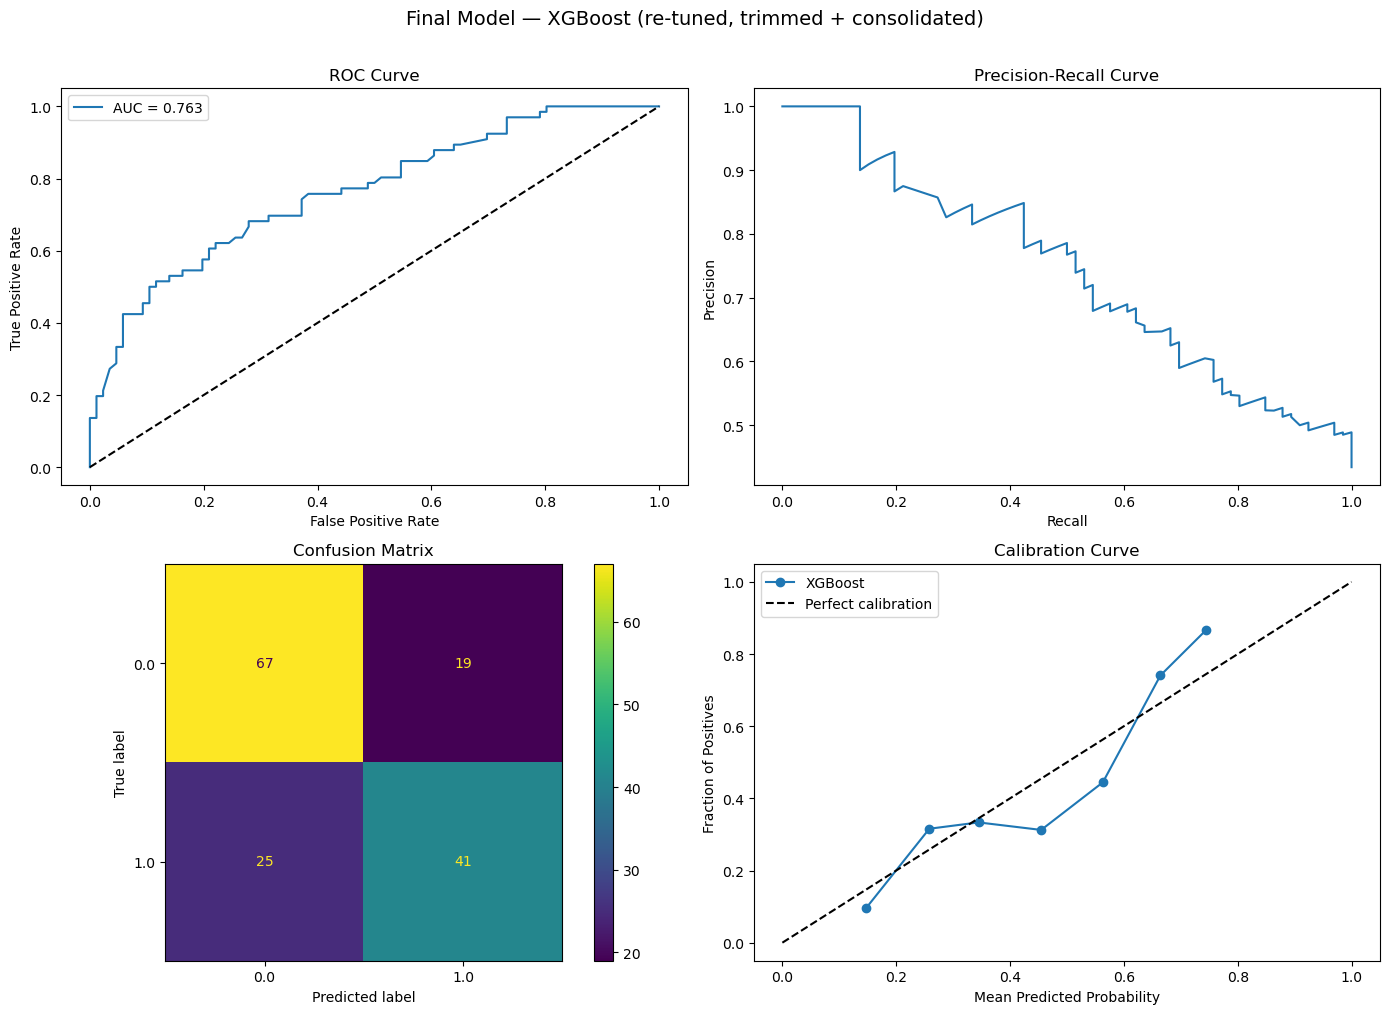


Feature Importance (mean absolute SHAP):
                                     feature  mean_abs_shap
#_of_charting_songs_through_first_top_20_hit       0.541973
       betweenness_centrality_top20_rolling5       0.269641
                          #_of_genres_artist       0.180520
                    artist_genre_Hip Hop/Rap       0.176357
                            artist_genre_Pop       0.174452
                          artist_genre_other       0.089562
harmonic_closeness_centrality_top20_rolling5       0.030678
                           artist_genre_Rock       0.011734
                  artist_genre_R&B/Soul/Funk       0.003843


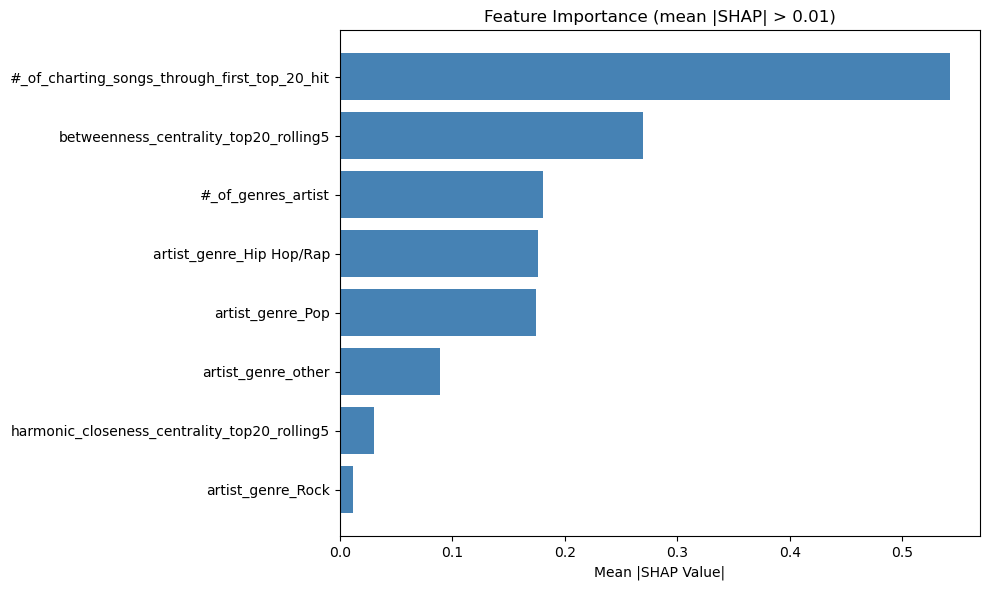

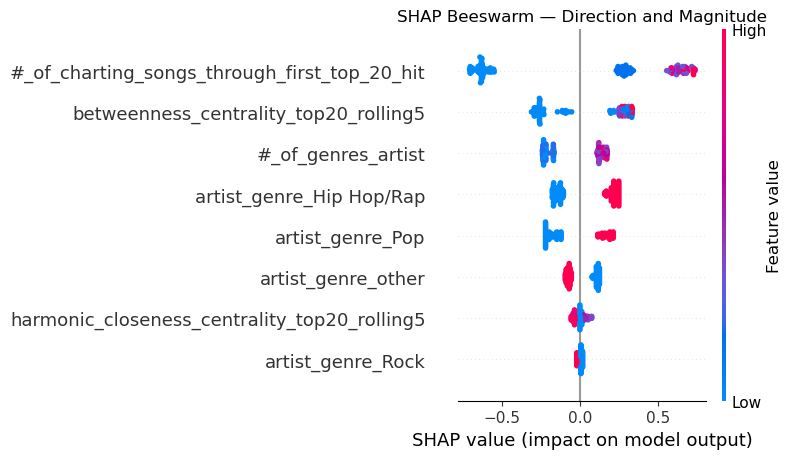

In [22]:
# Deep evaluation of re-tuned final XGBoost model (trimmed + genre-consolidated).
# Includes ROC curve, confusion matrix, precision-recall curve,
# SHAP feature importance, beeswarm plot, and calibration curve.

import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    roc_auc_score, log_loss, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import cross_validate

final_model = xgb_consolidated_search.best_estimator_
final_model.fit(X_train_consolidated, y_train)
y_pred  = final_model.predict(X_test_consolidated)
y_proba = final_model.predict_proba(X_test_consolidated)[:, 1]

cv = cross_validate(final_model, X_train_consolidated, y_train, cv=5,
                    scoring='roc_auc', return_train_score=True)

# --- Summary stats ---
print("=" * 52)
print("FINAL MODEL — XGBoost (re-tuned, trimmed + consolidated)")
print("=" * 52)
print(f"  ROC-AUC (CV):    {cv['test_score'].mean():.3f} ± {cv['test_score'].std():.3f}")
print(f"  ROC-AUC (Train): {cv['train_score'].mean():.3f}")
print(f"  ROC-AUC (Test):  {roc_auc_score(y_test, y_proba):.3f}")
print(f"  Overfit Gap:     {cv['train_score'].mean() - cv['test_score'].mean():.3f}")
print(f"  Log Loss:        {log_loss(y_test, y_proba):.3f}")
print(f"  Brier Score:     {brier_score_loss(y_test, y_proba):.3f}")
print(f"  Accuracy:        {accuracy_score(y_test, y_pred):.3f}")
print(f"  Precision:       {precision_score(y_test, y_pred):.3f}")
print(f"  Recall:          {recall_score(y_test, y_pred):.3f}")
print(f"  F1:              {f1_score(y_test, y_pred):.3f}")
print(f"\n{classification_report(y_test, y_pred)}")

# --- Diagnostic plots ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0, 0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[0, 1].plot(rec, prec)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix')

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker='o', label='XGBoost')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1, 1].set_xlabel('Mean Predicted Probability')
axes[1, 1].set_ylabel('Fraction of Positives')
axes[1, 1].set_title('Calibration Curve')
axes[1, 1].legend()

plt.suptitle('Final Model — XGBoost (re-tuned, trimmed + consolidated)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- SHAP ---
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_consolidated)

shap_importance = (
    pd.DataFrame({
        'feature':       X_test_consolidated.columns,
        'mean_abs_shap': np.abs(shap_values).mean(axis=0)
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)

print("\nFeature Importance (mean absolute SHAP):")
print(shap_importance.to_string(index=False))

top_features       = shap_importance[shap_importance['mean_abs_shap'] > 0.01]['feature'].tolist()
top_importance     = shap_importance[shap_importance['mean_abs_shap'] > 0.01]
top_idx            = [X_test_consolidated.columns.get_loc(f) for f in top_features]
shap_values_top    = shap_values[:, top_idx]
X_test_consolidated_top = X_test_consolidated[top_features]

# Bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_importance['feature'][::-1],
         top_importance['mean_abs_shap'][::-1], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('Feature Importance (mean |SHAP| > 0.01)')
plt.tight_layout()
plt.show()

# Beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_top, X_test_consolidated_top, plot_type='dot', show=False)
plt.title('SHAP Beeswarm — Direction and Magnitude')
plt.tight_layout()
plt.show()
